In [37]:
from matplotlib import pyplot as plt
import numpy as np
import re
import ast
from collections import  Counter

In [38]:
# load csv file (with title line)
def load_csv(file):
    with open(file, 'r') as f:
        lines = f.readlines()
    title = lines[0].strip().split(',')
    data = [list(map(float, line.strip().split(','))) for line in lines[1:]]
    return data

In [39]:
# plot
def plot(data):
    x = [int(row[0]) for row in data]
    y = [float(row[1]) for row in data]

    plt.plot(x, y)
    plt.xlabel('epoch')
    plt.ylabel('loss')
    plt.title('Loss')
    plt.show()


In [40]:
def getDict(log_file):
    log_dict = {}
    with open(log_file, 'r') as logs:
        weight_dict = None
        global topklist
        global bannedlist
        global clusterlist
        global banned_byround
        global indicator_list
        global attackers
        global tracerlist
        for line in logs:
            if 'attack_clients' in line:
                attackers = [int(x.strip()) for x in re.search(r'attack_clients:\s*\[(.*?)\]', line).group(1).strip().replace('  ', ' ').split(' ')]
                # attackers = [int(re.search(r'\((\-?\d+)\)', x).group(1)) for x in re.search(r'attack_clients\s*\[(.*?)\]', line).group(1).split(',')]
                # print(attackers)
            if 'Soft weight' in line:
                if 'nan' in line:
                    continue
                match = re.search(r"Soft weight (.*)", line)
                if match:
                    dict_str = match.group(1)

                    # Replace np.float64(x) with just x
                    dict_str = re.sub(r'np\.float64\(([^)]+)\)', r'\1', dict_str)

                    # Convert to dictionary
                    weight_dict = ast.literal_eval(dict_str)

                    # Convert values to numpy float64
                    weight_dict = {k: [np.float64(v) for v in vals] for k, vals in weight_dict.items()}

                    # print(weight_dict)
            if 'Round' in line:
                idx = int(line.strip().split()[8].strip(','))
                # print(idx)
                asr = float(line.strip().split()[-1])
                acc = float(line.strip().split()[-9].strip(','))
                log_dict[idx] = ((asr,acc), weight_dict if weight_dict is not None else None)
            if 'TSS top_k_indices' in line:
                topklist.append([int(x.strip()) for x in re.search(r'TSS top_k_indices\s*\[(.*?)\]', line).group(1).split(',')])
                # topklist.append([int(re.search(r'\((\-?\d+)\)', x).group(1)) for x in re.search(r'Top K\s*\[(.*?)\]', line).group(1).split(',')])
            
            if 'Top K' in line:
                topklist.append([int(x.strip()) for x in re.search(r'Top K \s*\[(.*?)\]', line).group(1).split(',')])
            
            if 'Tracer [' in line:
                tracerlist.append([int(x.strip()) for x in re.search(r'Tracer \s*\[(.*?)\]', line).group(1).split(',')])

            if 'Banned indices' in line:
                if re.search(r'Banned indices\s*\[(.*?)\]', line).group(1).replace('  ', ' ').strip().split(' ') == ['']:
                    pass
                else:
                    for i in [int(x.strip().strip(',')) for x in re.search(r'Banned indices\s*\[(.*?)\]', line).group(1).replace('  ', ' ').strip() if x.strip().strip(',') != '']:
                        if i in bannedlist.keys():
                            bannedlist[i] += 1
                        else:
                            bannedlist[i] = 1
                banned_byround.append([(int(x.strip().strip(',')) if x != '' else '') for x in re.search(r'Banned indices\s*\[(.*?)\]', line).group(1).replace('  ', ' ').strip().split(' ')])

            if 'Cluster labels' in line:
                if re.search(r'Cluster labels\s*\[(.*?)\]', line).group(1).split(' ') == ['']:
                    pass
                else:
                    for i, j in enumerate([int(x.strip()) for x in re.search(r'Cluster labels\s*\[(.*?)\]', line).group(1).split(' ')]):
                        if i not in clusterlist.keys():
                            clusterlist[i] = 0
                        clusterlist[i] += j

            if 'indicator labels' in line:
                if re.search(r'indicator labels\s*\[(.*?)\]', line).group(1).split(' ') == ['']:
                    pass
                else:
                    for i, j in enumerate([int(x.strip()) for x in re.search(r'indicator labels\s*\[(.*?)\]', line).group(1).split(' ')]):
                        if i not in clusterlist.keys():
                            clusterlist[i] = 0
                        clusterlist[i] += j

            if 'TSS indicator labels' in line:
                if re.search(r'TSS indicator labels\s*\[(.*?)\]', line).group(1).split(' ') == ['']:
                    pass
                else:
                    current_indicator = []
                    for i, j in enumerate([int(x.strip()) for x in re.search(r'TSS indicator labels\s*\[(.*?)\]', line).group(1).split(' ')]):
                        if j == 1:
                            current_indicator.append(i)
                    indicator_list.append(current_indicator)

                        

    return dict(sorted(log_dict.items()))

In [41]:
fl_dir = 'fl_save/debug/cifar10/dirichlet0.5/vgg_num-20_C-1/static/lr0.01ep3/GSS_11-12--05-31-00'

In [42]:
attackers = []
topklist = []
banned_byround = []
bannedlist = {}
clusterlist = {}
indicator_list = []
tracerlist = []
result_str = '{}/fed/results.csv'.format(fl_dir)
dataset, model, attack = result_str.split('/')[1], result_str.split('/')[3], result_str.split('/')[4]
data = load_csv(result_str)

In [43]:
try:
    log_file = "{}/main_parallel.py.log".format(fl_dir)
    log_dict = getDict(log_file)
except:
    log_file = "{}/attack_parallel.py.log".format(fl_dir)
    log_dict = getDict(log_file)

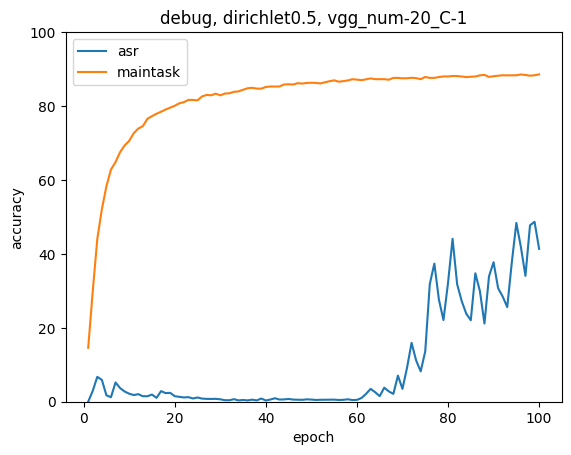

In [44]:

x = [int(row[0]) for row in data]
y = [float(row[-1]) for row in data]
y2 = [float(row[-4]) for row in data]

plt.plot(x, y, label='asr')
plt.plot(x, y2, label='maintask')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.ylim(0,100)
plt.title('{}, {}, {}'.format(dataset, model, attack))
plt.legend()
plt.show()

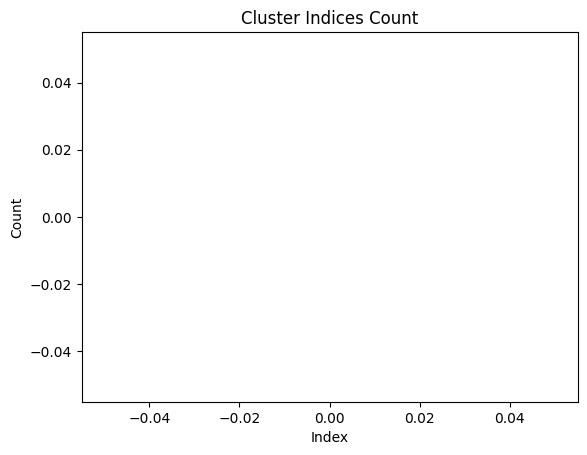

In [45]:
keys = list(clusterlist.keys())
values = list(clusterlist.values())

plt.bar(keys, values)
plt.xlabel('Index')
plt.ylabel('Count')
plt.title('Cluster Indices Count')
plt.show()

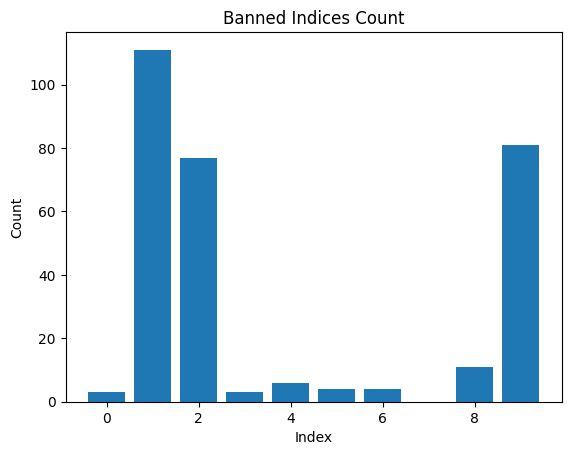

In [46]:
keys = list(bannedlist.keys())
values = list(bannedlist.values())

plt.bar(keys, values)
plt.xlabel('Index')
plt.ylabel('Count')
plt.title('Banned Indices Count')
plt.show()

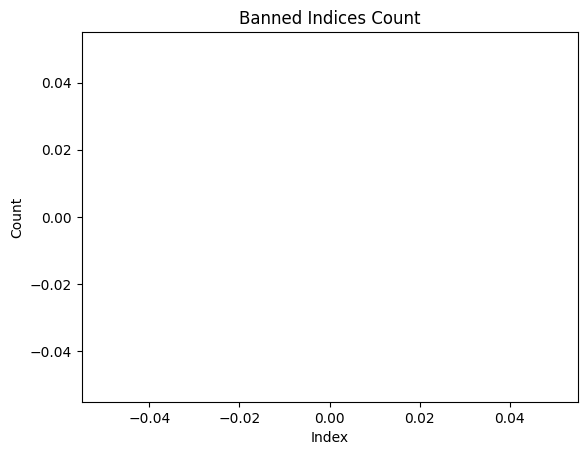

In [47]:
keys = list(clusterlist.keys())
values = list(clusterlist.values())

plt.bar(keys, values)
plt.xlabel('Index')
plt.ylabel('Count')
plt.title('Banned Indices Count')
plt.show()

In [48]:
# print(topklist[5:])
# topk_acc = (topklist[5:].count(attackers) + topklist[5:].count(attackers[::-1])) / (len(topklist[5:]) or 1)
# print(topk_acc)
# # print((np.count_nonzero(np.array(topklist[5:]).reshape(-1)==0)+np.count_nonzero(np.array(topklist[5:]).reshape(-1)==1)) / (len(np.array(topklist[5:]).reshape(-1)) or 1))
# topk_acc_partial = 0
# for attacker_ in attackers:
#     topk_acc_partial += (topklist[5:].count(attacker_) + topklist[5:].count(attacker_)) / (len(topklist[5:]) or 1)
# print(topk_acc_partial)
defense_start = 5
defense_end = 100
print(attackers)
print(topklist[defense_start:defense_end])

topk_acc = (topklist[defense_start:defense_end].count(attackers) + topklist[defense_start:defense_end].count(attackers[::-1])) / (len(topklist[defense_start:defense_end]) or 1)
print(topk_acc)

topk_acc_partial = 0
flat_array = np.array([item for sublist in topklist[defense_start:defense_end] for item in sublist if item != ''])
for attacker_ in attackers:
    topk_acc_partial += np.count_nonzero(flat_array == attacker_) / (len(flat_array) or 1)
print(topk_acc_partial)

# calculate FPR
# Calculate False Positive Rate (FPR)
# FPR = FP / (FP + TN)
# FP: number of non-attackers that are banned
# TN: number of non-attackers that are not banned

all_clients = set(range(max(flat_array if len(flat_array) > 0 else attackers) + 1))

non_attackers = list(all_clients - set(attackers))

fp = 0
tn = 0
for client in non_attackers:
    fp += np.count_nonzero(flat_array == client)
    tn += (defense_end - defense_start) - np.count_nonzero(flat_array == client)

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"FPR: {fpr}")

[2, 19]
[]
0.0
0.0
FPR: 0.0


In [49]:
defense_start = 5
defense_end = 25
print(topklist[defense_start:defense_end])
# print((topklist[defense_start:defense_end].count([0,1]) + topklist[defense_start:defense_end].count([1,0])) / (len(topklist[defense_start:defense_end]) or 1))
topk_acc = (topklist[defense_start:defense_end].count(attackers) + topklist[defense_start:defense_end].count(attackers[::-1])) / (len(topklist[defense_start:defense_end]) or 1)
print(topk_acc)
# print((np.count_nonzero(np.array(topklist[defense_start:defense_end]).reshape(-1)==0)+np.count_nonzero(np.array(topklist[defense_start:defense_end]).reshape(-1)==1)) / (len(np.array(topklist[defense_start:defense_end]).reshape(-1)) or 1))
topk_acc_partial = 0
for attacker_ in attackers:
    topk_acc_partial += (topklist[defense_start:defense_end].count(attacker_) + topklist[defense_start:defense_end].count(attacker_)) / (len(topklist[defense_start:defense_end]) or 1)
print(topk_acc_partial)

[]
0.0
0.0


In [50]:
defense_start = 5
defense_end = 100
print(attackers)
print(banned_byround[defense_start:defense_end])

# 计算[0,1]和[1,0]在列表中的比例
# print((banned_byround[defense_start:defense_end].count([0,1]) + banned_byround[defense_start:defense_end].count([1,0])) / (len(banned_byround[defense_start:defense_end]) or 1))
banned_acc = (banned_byround[defense_start:defense_end].count(attackers) + banned_byround[defense_start:defense_end].count(attackers[::-1])) / (len(banned_byround[defense_start:defense_end]) or 1)
print(banned_acc)

# # 修正：计算所有元素中0和1的比例
# flat_array = np.array([item for sublist in banned_byround[defense_start:defense_end] for item in sublist if item != ''])
# zeros_count = np.count_nonzero(flat_array == 0)
# ones_count = np.count_nonzero(flat_array == 1)
# print((zeros_count + ones_count) / (len(flat_array) or 1))
banned_acc_partial = 0
flat_array = np.array([item for sublist in banned_byround[defense_start:defense_end] for item in sublist if item != ''])
for attacker_ in attackers:
    banned_acc_partial += np.count_nonzero(flat_array == attacker_) / (len(flat_array) or 1)
print(banned_acc_partial)


all_clients = set(range(max(flat_array if len(flat_array) > 0 else attackers) + 1))

non_attackers = list(all_clients - set(attackers))

fp = 0
tn = 0
for client in non_attackers:
    fp += np.count_nonzero(flat_array == client)
    tn += (defense_end - defense_start) - np.count_nonzero(flat_array == client)

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"FPR: {fpr}")

[2, 19]
[[2, 19], [10, 18], [1, 14], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [0, 13], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [9, 11], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [2, 19], [8, 16], [8, 18], [1, 15], [2, 19], [2, 19], [8, 9], [2, 19], [2, 19], [1, 3], [2, 19], [1, 18], [11, 16], [2, 19], [2, 19], [1, 9], [11, 16], [1, 14], [2, 19], [2, 19], [1, 8], [14, 15], [2, 19], [2, 19], [2, 19], [2, 19], [12, 16], [2, 19], [2, 19], [14, 18], [0, 19], [2, 19], [2, 19], [2, 19], [3, 9], [1, 14], [2, 19], [2, 19], [8, 9], [2, 19], [2, 19]]
0.7684210526315789
0.7736842105263158
FPR: 0.025146198830409357


In [51]:
defense_start = 5
defense_end = 100
print(attackers)
print(indicator_list[defense_start:defense_end])

banned_acc = (indicator_list[defense_start:defense_end].count(attackers) + indicator_list[defense_start:defense_end].count(attackers[::-1])) / (len(indicator_list[defense_start:defense_end]) or 1)
print(banned_acc)

banned_acc_partial = 0
flat_array = np.array([item for sublist in indicator_list[defense_start:defense_end] for item in sublist if item != ''])
for attacker_ in attackers:
    banned_acc_partial += np.count_nonzero(flat_array == attacker_) / (len(flat_array) or 1)
print(banned_acc_partial)

# calculate FPR
# Calculate False Positive Rate (FPR)
# FPR = FP / (FP + TN)
# FP: number of non-attackers that are banned
# TN: number of non-attackers that are not banned

all_clients = set(range(max(flat_array if len(flat_array) > 0 else attackers) + 1))

non_attackers = list(all_clients - set(attackers))

fp = 0
tn = 0
for client in non_attackers:
    fp += np.count_nonzero(flat_array == client)
    tn += (defense_end - defense_start) - np.count_nonzero(flat_array == client)

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"FPR: {fpr}")

[2, 19]
[]
0.0
0.0
FPR: 0.0


In [52]:
defense_start = 5
defense_end = 100
print(attackers)
print(tracerlist[defense_start:defense_end])

banned_acc = (tracerlist[defense_start:defense_end].count(attackers) + tracerlist[defense_start:defense_end].count(attackers[::-1])) / (len(tracerlist[defense_start:defense_end]) or 1)
print(banned_acc)

banned_acc_partial = 0
flat_array = np.array([item for sublist in tracerlist[defense_start:defense_end] for item in sublist if item != ''])
for attacker_ in attackers:
    banned_acc_partial += np.count_nonzero(flat_array == attacker_) / (len(flat_array) or 1)
print(banned_acc_partial)

# calculate FPR
# Calculate False Positive Rate (FPR)
# FPR = FP / (FP + TN)
# FP: number of non-attackers that are banned
# TN: number of non-attackers that are not banned

all_clients = set(range(max(flat_array if len(flat_array) > 0 else attackers) + 1))
non_attackers = list(all_clients - set(attackers))

fp = 0
tn = 0
for client in non_attackers:
    fp += np.count_nonzero(flat_array == client)
    tn += (defense_end - defense_start) - np.count_nonzero(flat_array == client)

fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
print(f"FPR: {fpr}")

[2, 19]
[]
0.0
0.0
FPR: 0.0


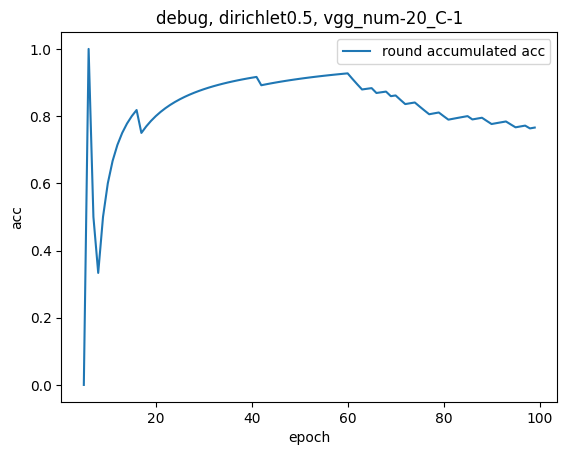

In [55]:
x = list(range(5, 100))
y = [(banned_byround[defense_start:i].count(attackers) + banned_byround[defense_start:i].count(attackers[::-1])) / (len(banned_byround[defense_start:i]) or 1) for i in range(5, 100)]
plt.plot(x, y, label='round accumulated acc')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.title('{}, {}, {}'.format(dataset, model, attack))
plt.legend()
plt.show()

In [54]:

x = [idx for idx, val in log_dict.items()]
y = [np.mean(val[1]['layer1.2.conv2']) for idx, val in log_dict.items()]
y2 = [val[0][0] for idx, val in log_dict.items()]
y3 = [val[0][1] for idx, val in log_dict.items()]
y4 = [val[1]['conv2'][:2] for idx, val in log_dict.items()]

plt.plot(x, y, label='weight mean')
plt.plot(x, y2, label='asr')
plt.plot(x, y3, label='main')
plt.plot(x, y4, label='weight attacker')
plt.xlabel('epoch')
plt.ylabel('val')
plt.title('{}, {}, {}'.format(dataset, model, attack))
plt.legend()
plt.show()

TypeError: 'NoneType' object is not subscriptable

In [ ]:

x = [idx for idx, val in log_dict.items()]
y = [val[1]['layer1.2.conv2'] for idx, val in log_dict.items()]

plt.violinplot(y)
plt.xlabel('epoch')
plt.ylabel('weight distribution')
plt.title('Weight Distribution of conv2 Layer')
plt.show()